# Notebook to plot the results from RANDOM FOREST REGRESSION

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

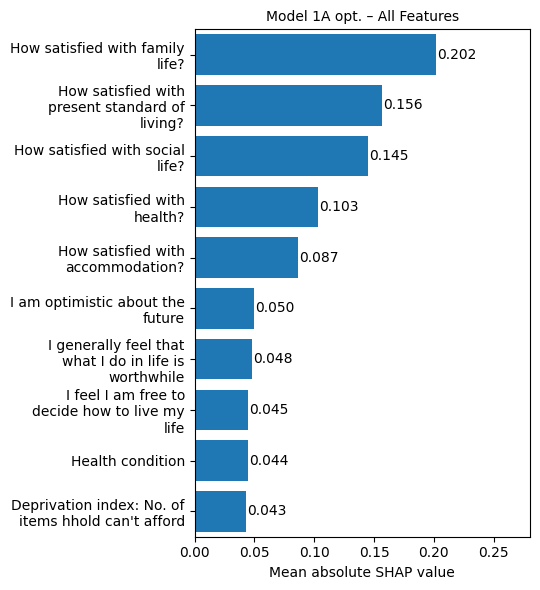

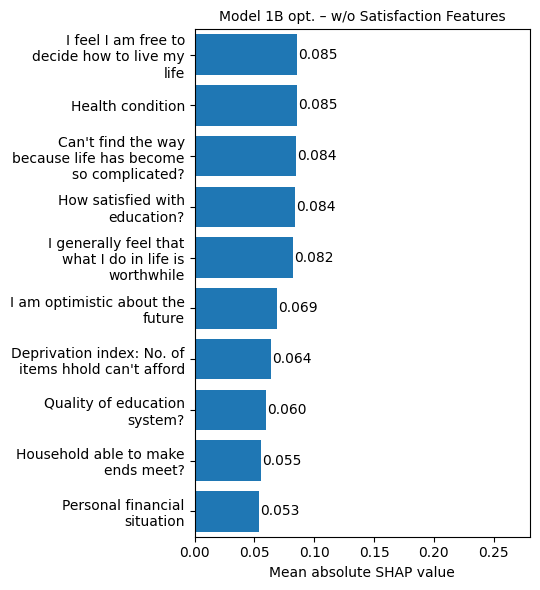

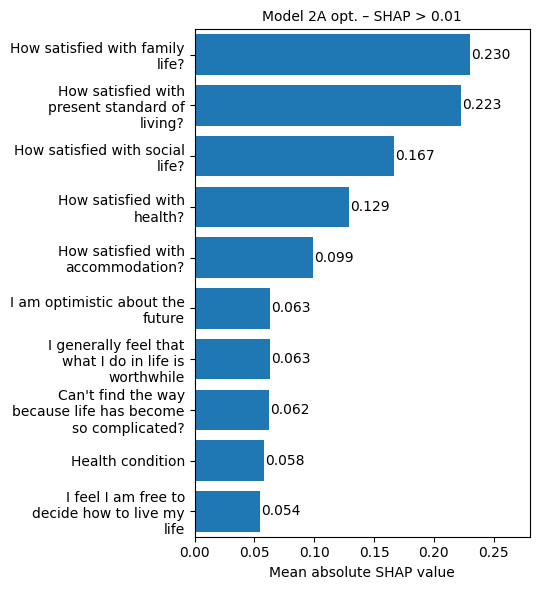

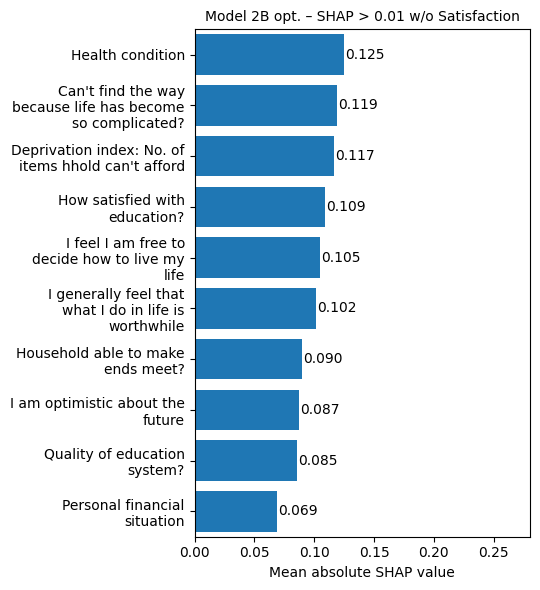

In [14]:
# Load Data
df_1A = pd.read_csv("data/RandomForestRegression/shap_results_1A_optimized.csv")
df_1B = pd.read_csv("data/RandomForestRegression/shap_results_1B_optimized.csv")
df_2A = pd.read_csv("data/RandomForestRegression/shap_results_2A_optimized.csv")
df_2B = pd.read_csv("data/RandomForestRegression/shap_results_2B_optimized.csv")

def plot_shap_large(df, title, max_questions=None):
    df_sorted = df.sort_values(by="Value", ascending=True).reset_index(drop=True)
    if max_questions:
        df_sorted = df_sorted.tail(max_questions).reset_index(drop=True)

    df_sorted["Questions"] = df_sorted["Questions"].apply(lambda x: "\n".join(textwrap.wrap(x, width=25)))

    n = len(df_sorted)
    plt.figure(figsize=(5.5, n * 0.6))
    bars = plt.barh(df_sorted["Questions"], df_sorted["Value"])

    # title 
    plt.xlabel("Mean absolute SHAP value", color='black', fontsize=10)
    plt.title(title, color='black', fontsize=10)

    xlim_max = max(
        df_1A["Value"].max(),
        df_1B["Value"].max(),
        df_2A["Value"].max(),
        df_2B["Value"].max()
    )
    plt.xlim(0, xlim_max+0.05)
    
    # Display values in the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.3f}",
                 va='center', fontsize=10)

    plt.ylim(-0.5, n - 0.5)
    plt.tight_layout()
    plt.show()

# Show plots
plot_shap_large(df_1A, "Model 1A opt. – All Features", max_questions=10)
plot_shap_large(df_1B, "Model 1B opt. Model 1B opt. – w/o Satisfaction Features", max_questions=10)
plot_shap_large(df_2A, "Model 2A opt. – SHAP > 0.01",max_questions=10)
plot_shap_large(df_2B, "Model 2B opt. – SHAP > 0.01 w/o Satisfaction", max_questions=10)
plt.show()

In [ ]:
def plot_combined_shap_bar(dfs, model_labels, title, top_n=20):
    """
    Creates a grouped bar chart comparing SHAP values across multiple models
    """
    # Collect all questions
    all_df = pd.concat(dfs)

    # Compute average SHAP value per question across all models
    mean_values = all_df.groupby("Questions")["Value"].mean().sort_values(ascending=False)
    top_questions = mean_values.head(top_n).index.tolist()

    # Prepare a new DataFrame to align SHAP values for each model
    data = pd.DataFrame({'Questions': top_questions})

    for df, label in zip(dfs, model_labels):
        merged = data[['Questions']].merge(df, on='Questions', how='left').rename(columns={'Value': label})
        data[label] = merged[label]

    # Group the bars
    bar_width = 0.2
    x = np.arange(len(top_questions))
    fig, ax = plt.subplots(figsize=(12, top_n * 0.4))
    colors = ['steelblue', 'orange', 'green', 'crimson']

    for i, label in enumerate(model_labels):
        ax.barh(x + i * bar_width, data[label], height=bar_width, label=label, color=colors[i])

    # Diagram settings
    ax.set_yticks(x + bar_width * (len(model_labels) - 1) / 2)
    ax.set_yticklabels(top_questions, fontsize=8)
    ax.set_xlabel("Mean absolute SHAP value", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# Funktion aufrufen
plot_combined_shap_bar(
    dfs=[df_1A, df_2A],
    model_labels=["1A - includes all questions", "2A - with <0.01 SHAP filter", ],
    title="Comparison of SHAP Values Across Models",
    top_n=30
)

# Funktion aufrufen
plot_combined_shap_bar(
    dfs=[df_1B, df_2B],
    model_labels=["1B - no satisfaction questions", "2B - no satisfaction questions with <0.01 SHAP filter", ],
    title="Comparison of SHAP Values Across Models",
    top_n=30
)